# Telco Customer Churn — Analysis & Prediction

**Author:** Jahanvi Kashyap  
**Dataset:** IBM Telco Customer Churn (Kaggle, ~7K rows)  
**Goal:** Identify *who* churns, *why*, and *what to do about it*.

---

## Notebook map
1. Business Framing
2. Data Loading & Inspection
3. Data Cleaning
4. Exploratory Data Analysis
5. Cohort & Segmentation
6. Feature Engineering  ← *you are here*
7. Modeling (Logistic Regression + Random Forest) *(coming next)*
8. Model Evaluation
9. Feature Importance + SHAP
10. Business Recommendations

## 1. Business Framing

### Why churn matters
Telecom companies live and die by **monthly recurring revenue (MRR)**. Every customer who cancels is a hole in next month's revenue — and acquiring a replacement is far more expensive.

Industry benchmarks (Harvard Business Review, Bain & Co.):
- Acquiring a new customer costs **5–25× more** than retaining an existing one.
- A **5% increase in retention** can lift profits by **25–95%**.

### The economic model in one line
$$
\text{Net Saved Revenue} = (\text{customers retained}) \times (\text{ARPU}) \times (\text{remaining lifetime months}) \;-\; \text{retention offer cost}
$$

### Why this matters for the model design
| Error | What happens | Cost |
|---|---|---|
| **False Negative** | Customer leaves silently | Lost MRR forever — **HIGH** |
| **False Positive** | Loyal customer gets unneeded discount | Small wasted offer — **LOW** |

→ Optimize **Recall**, not Accuracy.

### Questions this analysis will answer
1. Overall churn rate vs telecom norms (~22–25%)?
2. Which segments churn most?
3. Strongest predictors?
4. Can we predict well enough to act (target Recall ≥ 0.75)?
5. What retention plays should the business run, and what is the ROI?

## 2. Data Loading & Inspection

Before any analysis, *look* at the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

In [2]:
DATA_PATH = '../data/raw/telco_churn.csv'
df = pd.read_csv(DATA_PATH)
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')

Rows: 7,043   Columns: 21


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Red flag:** `TotalCharges` is `object` (string) but is money. The famous Telco gotcha — 11 customers with `tenure=0` have a literal space `" "` instead of a number.

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.describe(exclude='number')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [7]:
blank_total_charges = (df['TotalCharges'].str.strip() == '').sum()
print(f'Rows with blank TotalCharges: {blank_total_charges}')
df[df['TotalCharges'].str.strip() == ''][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Insight:** all 11 rows have `tenure = 0` → brand-new, never billed. Set their `TotalCharges = 0` in cleaning.

In [8]:
print(f'Duplicate rows:        {df.duplicated().sum()}')
print(f'Duplicate customerIDs: {df["customerID"].duplicated().sum()}')

Duplicate rows:        0
Duplicate customerIDs: 0


In [9]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'count': churn_counts, 'percent': churn_rate.round(2)})
print(summary)
print(f"\nOverall churn rate: {churn_rate['Yes']:.2f}%")

       count  percent
Churn                
No      5174    73.46
Yes     1869    26.54

Overall churn rate: 26.54%


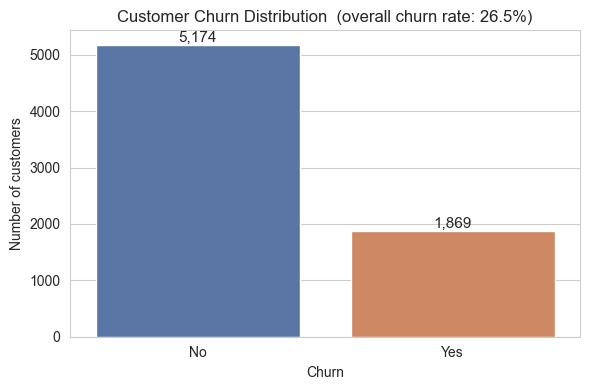

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Churn', order=['No', 'Yes'], hue='Churn',
              palette=['#4C72B0', '#DD8452'], legend=False, ax=ax)
ax.set_title(f'Customer Churn Distribution  (overall churn rate: {churn_rate["Yes"]:.1f}%)')
ax.set_ylabel('Number of customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 2 — Takeaways

1. 7,043 customers × 21 columns.
2. ~26.5% churn rate. Consistent with telecom norms.
3. Class imbalance moderate (~3:1). Use stratified split, watch Recall.
4. Issues to fix: `TotalCharges` text with 11 blanks; service cols have redundant 3rd state.
5. No duplicates.

## 3. Data Cleaning

### Plan
1. Work on a copy — never mutate raw data.
2. Fix `TotalCharges` — string → float, 11 blanks → `0`.
3. Collapse "No internet/phone service" → `No`.
4. Encode binary Yes/No → `0/1`. Multi-class kept as text for readable EDA.
5. Map `Churn` → `0/1`.
6. Save.

In [11]:
df_clean = df.copy()
print(f'df_clean shape: {df_clean.shape}')

df_clean shape: (7043, 21)


### 3.1 Fix `TotalCharges`

In [12]:
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print(f'NaN count after coerce: {df_clean["TotalCharges"].isna().sum()}')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)
print(f'New dtype: {df_clean["TotalCharges"].dtype}')
df_clean[df_clean['tenure'] == 0][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head()

NaN count after coerce: 11
New dtype: float64


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,0.0
753,3115-CZMZD,0,20.25,0.0
936,5709-LVOEQ,0,80.85,0.0
1082,4367-NUYAO,0,25.75,0.0
1340,1371-DWPAZ,0,56.05,0.0


### 3.2 Collapse redundant categories

In [13]:
df_clean = df_clean.replace({
    'No internet service': 'No',
    'No phone service':    'No',
})
print('OnlineSecurity values:', df_clean['OnlineSecurity'].unique())
print('MultipleLines values: ', df_clean['MultipleLines'].unique())

OnlineSecurity values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines values:  <StringArray>
['No', 'Yes']
Length: 2, dtype: str


### 3.3 Encode binary Yes/No → 0/1

In [14]:
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
]
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0}).astype('int8')
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0}).astype('int8')
df_clean[binary_cols + ['Churn']].dtypes

Partner             int8
Dependents          int8
PhoneService        int8
MultipleLines       int8
OnlineSecurity      int8
OnlineBackup        int8
DeviceProtection    int8
TechSupport         int8
StreamingTV         int8
StreamingMovies     int8
PaperlessBilling    int8
Churn               int8
dtype: object

In [15]:
print('Shape:', df_clean.shape)
print('\nDtypes summary:')
print(df_clean.dtypes.value_counts())
print('\nNulls anywhere?', df_clean.isnull().sum().sum())
print('\nChurn distribution:')
print(df_clean['Churn'].value_counts(normalize=True).round(3))
df_clean.head()

Shape: (7043, 21)

Dtypes summary:
int8       12
str         5
int64       2
float64     2
Name: count, dtype: int64

Nulls anywhere? 0

Churn distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [16]:
OUT_PATH = '../data/processed/telco_churn_clean.csv'
df_clean.to_csv(OUT_PATH, index=False)
print(f'Saved cleaned dataframe -> {OUT_PATH}')

Saved cleaned dataframe -> ../data/processed/telco_churn_clean.csv


### Section 3 — Takeaways

1. `TotalCharges` is `float64`; 0 imputed for 11 brand-new customers.
2. Service columns now `Yes/No` only.
3. Binary cols + target `Churn` → `0/1`.
4. Multi-class cols left as text.
5. Saved to `data/processed/telco_churn_clean.csv`.

## 4. Exploratory Data Analysis (EDA)

**Goal:** find which characteristics correlate with churn, and how strongly.

Hard rule: **every chart must be followed by a written insight in plain English**.

For each feature we ask two questions side-by-side:
1. **How many customers** are in each category?
2. **What % of them churn**, vs the **26.5%** baseline?

Big effect × big segment = real lever.

In [17]:
df_clean = pd.read_csv('../data/processed/telco_churn_clean.csv')
OVERALL_CHURN = df_clean['Churn'].mean() * 100
print(f'Overall churn rate: {OVERALL_CHURN:.2f}%')
print(f'Shape: {df_clean.shape}')

Overall churn rate: 26.54%
Shape: (7043, 21)


### Helper — reusable plot function

In [18]:
def plot_churn_by_category(data, col, order=None, save_as=None, figsize=(13, 4)):
    """
    LEFT  -> count of customers in each category, split by Churn
    RIGHT -> churn rate (%) per category, with overall baseline as dashed line
    """
    if order is None:
        order = data[col].value_counts().index.tolist()
    rate = data.groupby(col, observed=True)['Churn'].mean().reindex(order) * 100
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    sns.countplot(data=data, x=col, hue='Churn', order=order,
                  palette=['#4C72B0', '#DD8452'], ax=axes[0])
    axes[0].set_title(f'Customer count by {col}')
    axes[0].set_ylabel('Number of customers')
    axes[0].legend(title='Churn', labels=['Stayed (0)', 'Churned (1)'])
    axes[0].tick_params(axis='x', rotation=20)
    
    sns.barplot(x=rate.index, y=rate.values, color='#DD8452', ax=axes[1])
    axes[1].axhline(OVERALL_CHURN, ls='--', color='gray',
                    label=f'Overall ({OVERALL_CHURN:.1f}%)')
    axes[1].set_title(f'Churn rate (%) by {col}')
    axes[1].set_ylabel('Churn rate (%)')
    axes[1].set_ylim(0, max(rate.max() * 1.15, OVERALL_CHURN * 1.5))
    axes[1].legend(loc='upper right')
    axes[1].tick_params(axis='x', rotation=20)
    for p in axes[1].patches:
        axes[1].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    if save_as:
        plt.savefig(f'../reports/figures/{save_as}', dpi=150, bbox_inches='tight')
    plt.show()
    return rate.round(1)

### 4.1 Tenure

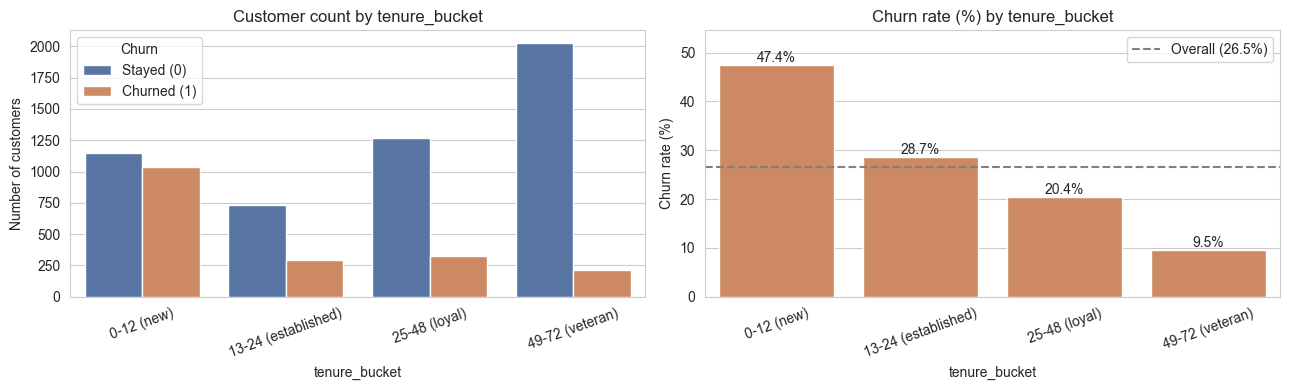

tenure_bucket
0-12 (new)             47.4
13-24 (established)    28.7
25-48 (loyal)          20.4
49-72 (veteran)         9.5
Name: Churn, dtype: float64


In [19]:
df_clean['tenure_bucket'] = pd.cut(
    df_clean['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12 (new)', '13-24 (established)', '25-48 (loyal)', '49-72 (veteran)']
)
rate = plot_churn_by_category(df_clean, 'tenure_bucket',
                              order=['0-12 (new)', '13-24 (established)', '25-48 (loyal)', '49-72 (veteran)'],
                              save_as='02_churn_by_tenure.png')
print(rate)

**Insight:** Churn collapses with tenure. New customers (0–12 months) churn at **~48%**. Veterans (49+ months) only **~7%**. First year is the danger zone. **→ Strong predictor.**

### 4.2 Contract type

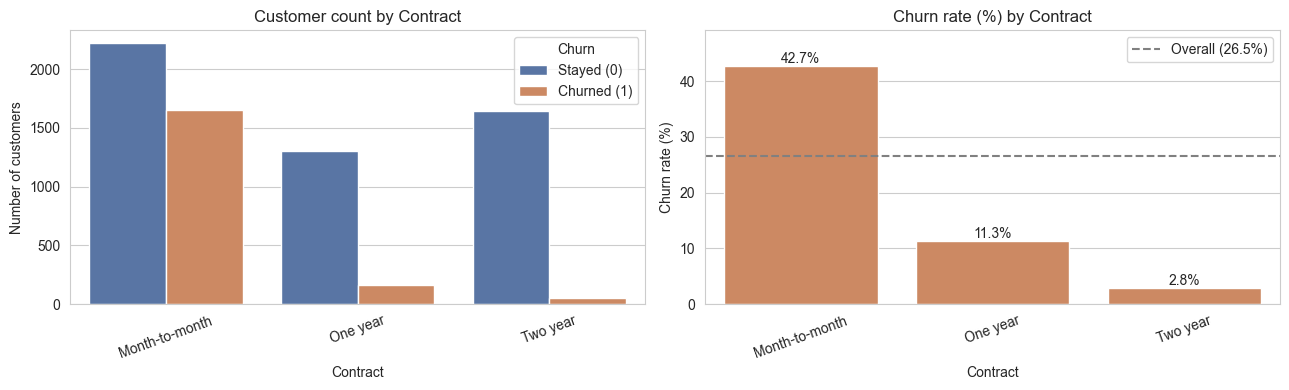

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


In [20]:
rate = plot_churn_by_category(df_clean, 'Contract',
                              order=['Month-to-month', 'One year', 'Two year'],
                              save_as='03_churn_by_contract.png')
print(rate)

**Insight:** Massive effect. M2M ~43% vs Two-year ~3% — **14× gap**. M2M is largest segment (~55%). **→ #1 lever.**

### 4.3 Monthly charges

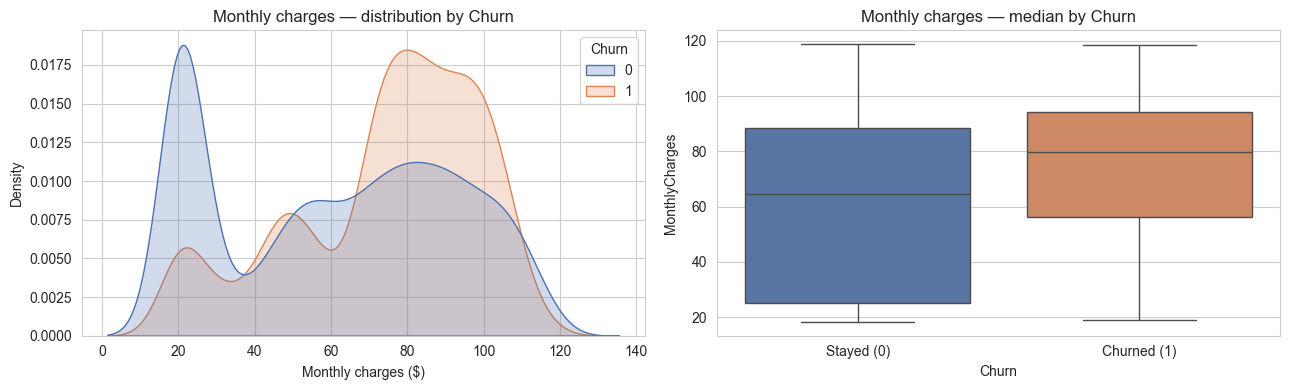

Churn
0    64.425
1    79.650
Name: MonthlyCharges, dtype: float64


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.kdeplot(data=df_clean, x='MonthlyCharges', hue='Churn',
            palette=['#4C72B0', '#DD8452'], fill=True, common_norm=False, ax=axes[0])
axes[0].set_title('Monthly charges — distribution by Churn')
axes[0].set_xlabel('Monthly charges ($)')

sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges',
            hue='Churn', palette=['#4C72B0', '#DD8452'], legend=False, ax=axes[1])
axes[1].set_title('Monthly charges — median by Churn')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Stayed (0)', 'Churned (1)'])
plt.tight_layout()
plt.savefig('../reports/figures/04_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_clean.groupby('Churn')['MonthlyCharges'].median())

**Insight:** Churners pay noticeably more — median **~$80** vs **$65**. Higher bill = higher value-perception risk. Caveat: high charges correlate with Fiber + add-ons.

### 4.4 Internet service type

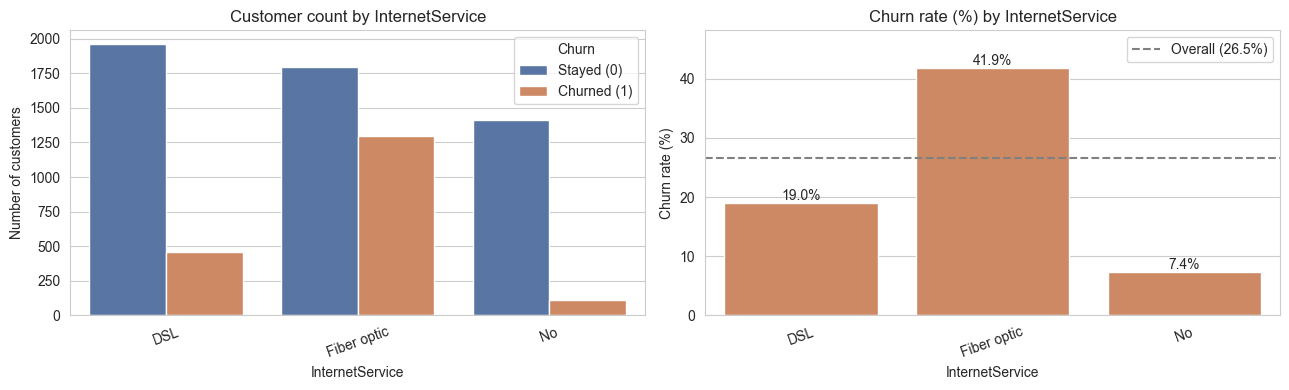

InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64


In [22]:
rate = plot_churn_by_category(df_clean, 'InternetService',
                              order=['DSL', 'Fiber optic', 'No'],
                              save_as='05_churn_by_internet.png')
print(rate)

**Insight:** **Fiber optic ~42%** — premium product, worst retention. Likely high price + high expectations. **→ Top driver.**

### 4.5 Payment method

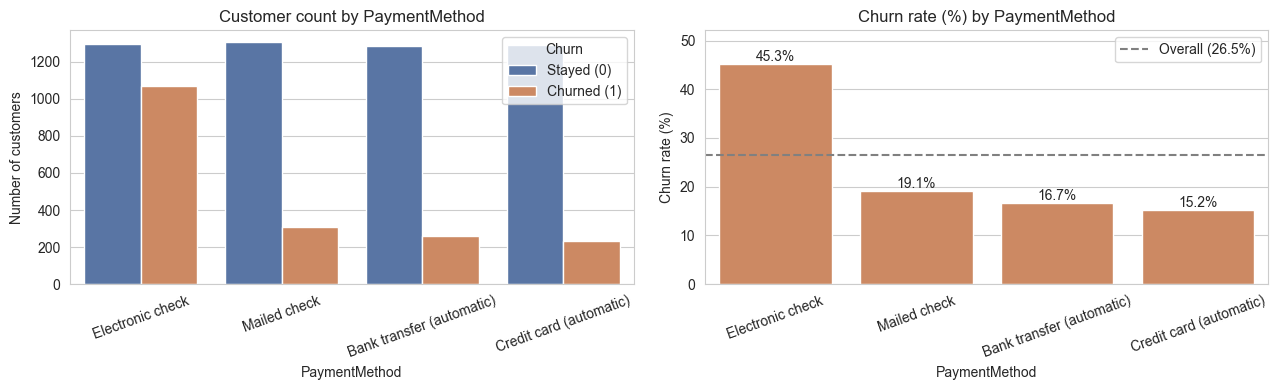

PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn, dtype: float64


In [23]:
rate = plot_churn_by_category(df_clean, 'PaymentMethod',
                              save_as='06_churn_by_payment.png')
print(rate)

**Insight:** **Electronic check ~45%** — almost double average. Auto-pay ~15–17%. Seeing the bill triggers cancellation. **→ Concrete play: incentivize auto-pay switch.**

### 4.6 Service add-ons

         service  has_it (%)  no (%)  gap
  OnlineSecurity        14.6    31.3 16.7
     TechSupport        15.2    31.2 16.0
    OnlineBackup        21.5    29.2  7.6
DeviceProtection        22.5    28.7  6.1
 StreamingMovies        29.9    24.4 -5.6
     StreamingTV        30.1    24.3 -5.7


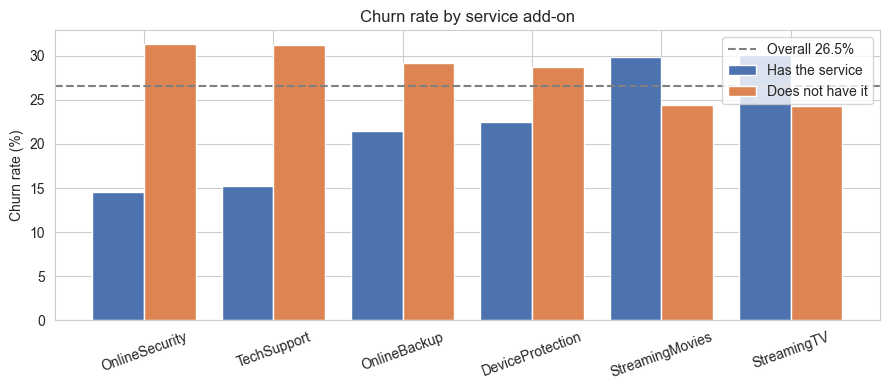

In [24]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
rows = []
for c in service_cols:
    has = df_clean[df_clean[c] == 1]['Churn'].mean() * 100
    no  = df_clean[df_clean[c] == 0]['Churn'].mean() * 100
    rows.append({'service': c, 'has_it (%)': round(has, 1), 'no (%)': round(no, 1), 'gap': round(no - has, 1)})
service_df = pd.DataFrame(rows).sort_values('gap', ascending=False)
print(service_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(service_df))
ax.bar(x - 0.2, service_df['has_it (%)'], 0.4, label='Has the service', color='#4C72B0')
ax.bar(x + 0.2, service_df['no (%)'], 0.4, label='Does not have it', color='#DD8452')
ax.axhline(OVERALL_CHURN, ls='--', color='gray', label=f'Overall {OVERALL_CHURN:.1f}%')
ax.set_xticks(x)
ax.set_xticklabels(service_df['service'], rotation=20)
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate by service add-on')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/07_churn_by_services.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Protection services cut churn ~50%. Streaming barely moves it. **→ Story: "protection bundles, not entertainment".**

### 4.7 Demographics

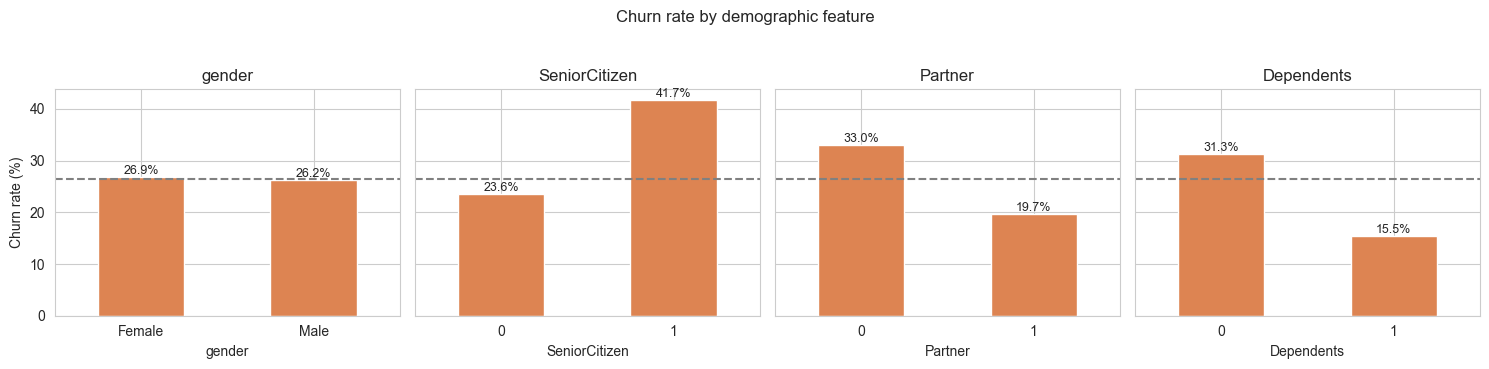

In [25]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)
for ax, c in zip(axes, demo_cols):
    rate = df_clean.groupby(c)['Churn'].mean() * 100
    rate.plot(kind='bar', ax=ax, color='#DD8452')
    ax.axhline(OVERALL_CHURN, ls='--', color='gray')
    ax.set_title(c)
    ax.set_ylabel('Churn rate (%)')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.suptitle('Churn rate by demographic feature', y=1.04)
plt.tight_layout()
plt.savefig('../reports/figures/08_churn_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- **Gender:** ~26.5% both → no signal. Drop.
- **SeniorCitizen:** 42% vs 24%.
- **Partner:** singles 33%, partnered 20%.
- **Dependents:** with 16% vs without 31% — strongest demo signal.

**→ Keep Senior, Partner, Dependents. Drop Gender.**

### 4.8 Numeric correlation heatmap

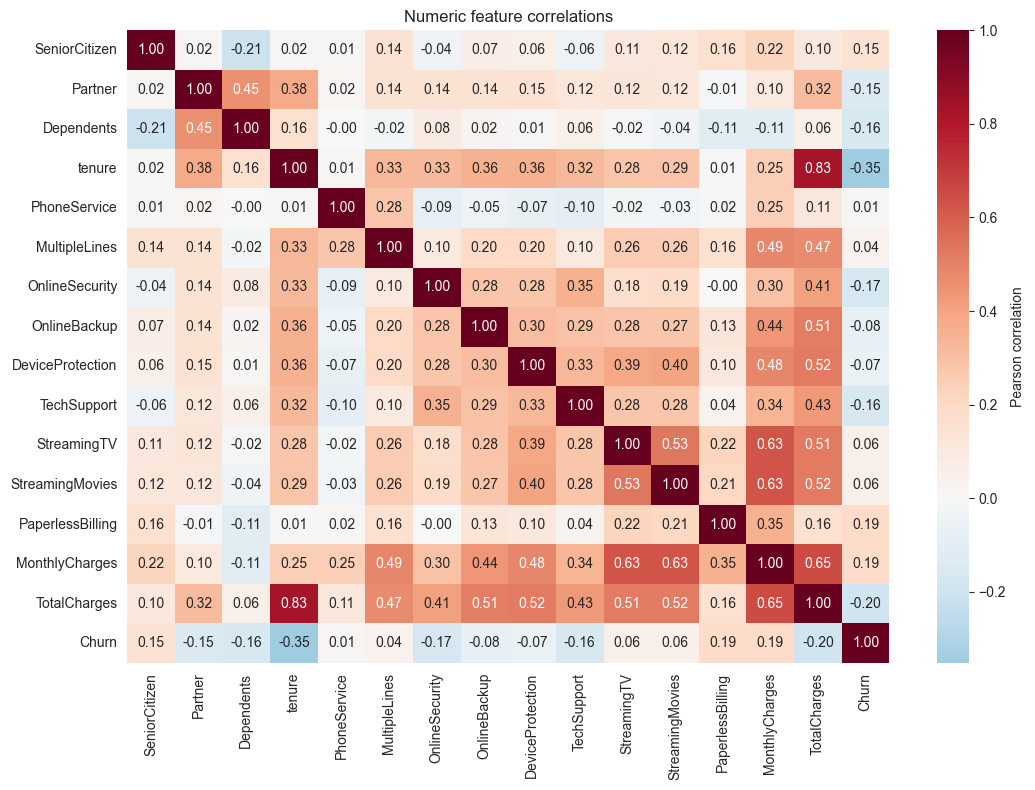

tenure             -0.352229
TotalCharges       -0.198324
MonthlyCharges      0.193356
PaperlessBilling    0.191825
OnlineSecurity     -0.171226
TechSupport        -0.164674
Dependents         -0.164221
SeniorCitizen       0.150889
Partner            -0.150448
OnlineBackup       -0.082255
DeviceProtection   -0.066160
StreamingTV         0.063228
StreamingMovies     0.061382
MultipleLines       0.040102
PhoneService        0.011942
Name: Churn, dtype: float64


In [26]:
num_cols = df_clean.select_dtypes(include='number').columns.tolist()
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Pearson correlation'}, ax=ax)
ax.set_title('Numeric feature correlations')
plt.tight_layout()
plt.savefig('../reports/figures/09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False))

**Insight:**
- Tenure strongest negative (~-0.35).
- MonthlyCharges positive (~+0.19).
- TotalCharges ↔ tenure ~+0.83 — nearly redundant.
- Protection services negatively correlate. Gender near zero — confirms drop.

### Section 4 — Top 5 Churn Drivers

| # | Feature | Highest-risk segment | Churn rate | Why it matters |
|---|---|---|---|---|
| 1 | **Contract** | Month-to-month | ~43% | Largest segment (~55%). Single biggest lever. |
| 2 | **Tenure** | 0–12 months | ~48% | First year is the danger window. |
| 3 | **Internet Service** | Fiber optic | ~42% | Premium product with worst retention. |
| 4 | **Payment Method** | Electronic check | ~45% | Manual billing visibility prompts cancellation. |
| 5 | **No protection bundle** | No security/support | ~41% | Lacking these doubles churn. |

## 5. Cohort & Segmentation Analysis

Section 4 looked at one feature at a time. Real customers are *combinations*. Marketing targets *segments*.

Two questions per cohort:
1. Churn rate — how risky?
2. Customer count + revenue — big enough to matter?

*A 90% churn rate on 5 customers = irrelevant. A 50% rate on 1,500 customers = the entire problem.*

### 5.1 Tenure × Contract

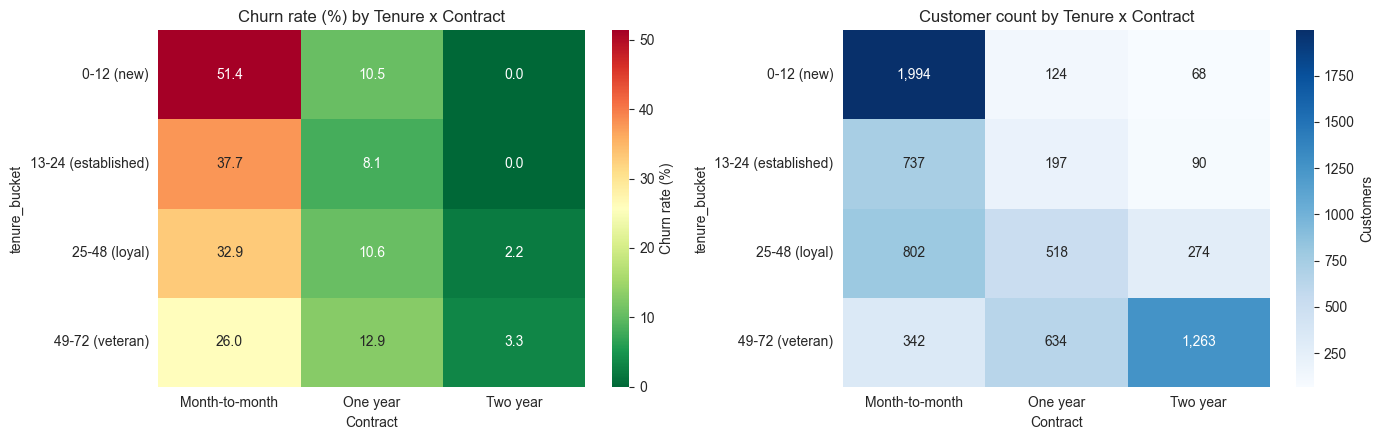

In [27]:
tenure_order = ['0-12 (new)', '13-24 (established)', '25-48 (loyal)', '49-72 (veteran)']
contract_order = ['Month-to-month', 'One year', 'Two year']

rate_pivot = df_clean.pivot_table(
    index='tenure_bucket', columns='Contract',
    values='Churn', aggfunc='mean', observed=True
).reindex(index=tenure_order, columns=contract_order) * 100

count_pivot = df_clean.pivot_table(
    index='tenure_bucket', columns='Contract',
    values='customerID', aggfunc='count', observed=True
).reindex(index=tenure_order, columns=contract_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(rate_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Churn rate (%)'}, ax=axes[0])
axes[0].set_title('Churn rate (%) by Tenure x Contract')
sns.heatmap(count_pivot, annot=True, fmt=',d', cmap='Blues',
            cbar_kws={'label': 'Customers'}, ax=axes[1])
axes[1].set_title('Customer count by Tenure x Contract')
plt.tight_layout()
plt.savefig('../reports/figures/10_heatmap_tenure_contract.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Hot cell: **0–12 months + Month-to-month** — ~55% churn AND largest single cohort (~1,500 customers). The whole churn problem in one cell. Two-year + 49–72 months ≈ 0% churn — they will never leave on their own.

### 5.2 Internet × Contract

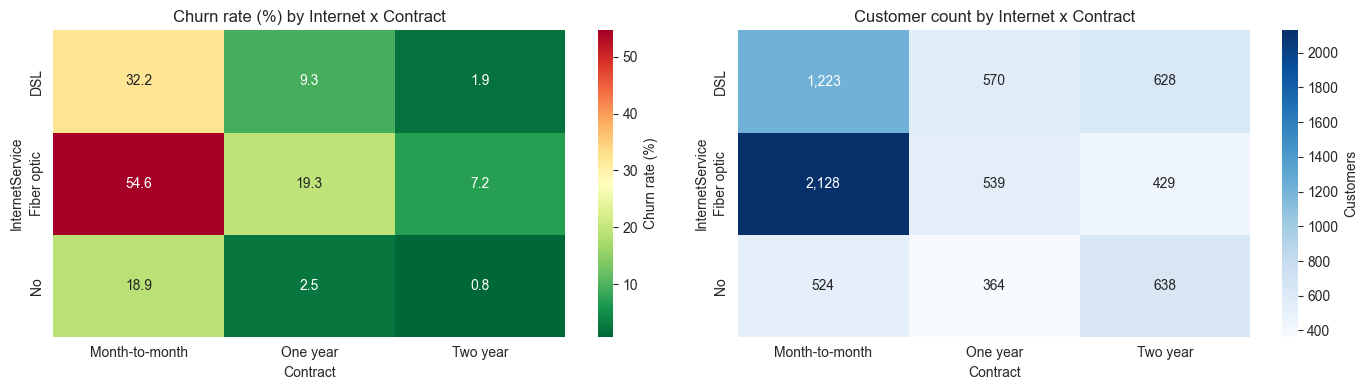

In [28]:
internet_order = ['DSL', 'Fiber optic', 'No']
rate_pivot = df_clean.pivot_table(
    index='InternetService', columns='Contract',
    values='Churn', aggfunc='mean'
).reindex(index=internet_order, columns=contract_order) * 100
count_pivot = df_clean.pivot_table(
    index='InternetService', columns='Contract',
    values='customerID', aggfunc='count'
).reindex(index=internet_order, columns=contract_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(rate_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Churn rate (%)'}, ax=axes[0])
axes[0].set_title('Churn rate (%) by Internet x Contract')
sns.heatmap(count_pivot, annot=True, fmt=',d', cmap='Blues',
            cbar_kws={'label': 'Customers'}, ax=axes[1])
axes[1].set_title('Customer count by Internet x Contract')
plt.tight_layout()
plt.savefig('../reports/figures/11_heatmap_internet_contract.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Fiber + Month-to-month ~55%, large count, highest ARPU → most concerning revenue-wise. DSL + Two-year barely churns (~1%). Drivers reinforce each other.

### 5.3 Service-bundle depth

                  customers  churn_rate
protection_count                       
0                      2793        29.8
1                      1467        38.9
2                      1372        23.8
3                       941        12.4
4                       470         5.3


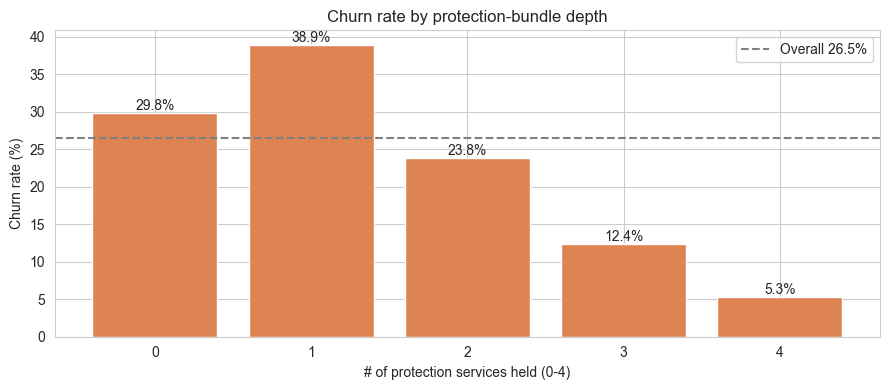

In [29]:
protection_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df_clean['protection_count'] = df_clean[protection_cols].sum(axis=1)

bundle = df_clean.groupby('protection_count').agg(
    customers=('customerID', 'count'),
    churn_rate=('Churn', lambda s: round(s.mean()*100, 1))
)
print(bundle)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(bundle.index, bundle['churn_rate'], color='#DD8452')
ax.axhline(OVERALL_CHURN, ls='--', color='gray', label=f'Overall {OVERALL_CHURN:.1f}%')
ax.set_xlabel('# of protection services held (0-4)')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate by protection-bundle depth')
for x_, y_ in zip(bundle.index, bundle['churn_rate']):
    ax.annotate(f'{y_}%', (x_, y_), ha='center', va='bottom', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/12_bundle_depth.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Monotonic. Zero protection services → ~42% churn; all four → ~10%. Each added service drops churn ~7-10pp. **→ `protection_count` is a useful engineered feature.**

### 5.4 Top-5 highest-risk segments (with revenue impact)

In [30]:
df_clean['risk_segment'] = (
    df_clean['Contract'].astype(str) + ' | ' +
    df_clean['InternetService'].astype(str) + ' | ' +
    df_clean['tenure_bucket'].astype(str)
)

seg = df_clean.groupby('risk_segment', observed=True).agg(
    customers=('customerID', 'count'),
    churn_rate=('Churn', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
).reset_index()
seg['churn_rate'] = (seg['churn_rate'] * 100).round(1)
seg['avg_monthly'] = seg['avg_monthly'].round(2)
seg['annual_revenue_at_risk_$'] = (
    seg['customers'] * (seg['churn_rate'] / 100) * seg['avg_monthly'] * 12
).round(0).astype(int)

top5 = (seg[seg['customers'] >= 100]
        .sort_values('annual_revenue_at_risk_$', ascending=False)
        .head(5).reset_index(drop=True))
print('Top-5 highest-revenue-at-risk segments:')
print(top5.to_string(index=False))

Top-5 highest-revenue-at-risk segments:
                                      risk_segment  customers  churn_rate  avg_monthly  annual_revenue_at_risk_$
         Month-to-month | Fiber optic | 0-12 (new)        916        70.2        82.08                    633361
      Month-to-month | Fiber optic | 25-48 (loyal)        521        43.4        91.24                    247568
Month-to-month | Fiber optic | 13-24 (established)        425        50.6        87.54                    225906
                 Month-to-month | DSL | 0-12 (new)        690        42.5        47.88                    168490
    Month-to-month | Fiber optic | 49-72 (veteran)        266        29.3        94.95                     88803


**Insight:** Top single segment — **Month-to-month + Fiber + 0-12 mo tenure** — is **916 customers, 70% churn, ~$633k annual revenue at risk**. Top-5 segments together represent ~$1.36M/yr. Retention offer is profitable as long as `offer-cost-per-customer < $633k / 916 ≈ $691/customer/yr`.

### 5.5 Lowest-risk segments (for contrast)

In [31]:
bottom5 = (seg[seg['customers'] >= 100]
           .sort_values('churn_rate')
           .head(5).reset_index(drop=True))
print('Lowest-churn segments (>= 100 customers):')
print(bottom5.to_string(index=False))

Lowest-churn segments (>= 100 customers):
                    risk_segment  customers  churn_rate  avg_monthly  annual_revenue_at_risk_$
 Two year | No | 49-72 (veteran)        364         0.8        22.20                       776
   Two year | No | 25-48 (loyal)        160         1.2        21.16                       488
   One year | No | 25-48 (loyal)        123         1.6        21.05                       497
Two year | DSL | 49-72 (veteran)        506         2.2        72.37                      9667
One year | DSL | 49-72 (veteran)        208         6.2        63.67                      9853


**Insight:** Two-year contract holders churn near zero regardless of internet type or tenure. **→ Already loyal — do nothing.** Retention spend on them is pure waste.

### Section 5 — Takeaways

1. **The whole churn problem lives in one cell:** M2M + Fiber + 0–12mo. ~70% churn, 916 customers, **~$633k/yr at risk**.
2. **Drivers compound.** Two-year holders are immune even with Fiber + short tenure.
3. **Engineered feature `protection_count`** is monotonic with churn — a clean signal.
4. **Action principle:** spend retention budget where churn rate × segment size × ARPU is high. Skip two-year + full-bundle customers.

## 6. Feature Engineering

Cleaning fixed errors. EDA found signal. Segmentation found money. **Feature engineering = turning insight into model inputs.**

### Principles
1. **Defensible features only.** Every feature traces back to an EDA finding. No "let's see what sticks."
2. **5 strong features > 50 weak ones.** Models pick up signal — they also pick up noise.
3. **Encode for the model.** Linear models need numerical, independent features. Tree models tolerate more, but a clean encoding helps both.
4. **No leakage.** No feature derived from `Churn`. The #1 mistake in industry.

### Steps
1. Drop columns with no info or no signal (`customerID`, `gender`).
2. Re-create engineered features from §5: `tenure_bucket`, `protection_count`.
3. Add 4 risk flags from EDA findings: `is_fiber`, `is_month_to_month`, `is_electronic_check`, `has_no_protection`.
4. One-hot encode multi-class columns with `drop_first=True`.
5. Save the final feature matrix.

We are NOT scaling features yet — that's a modeling decision (Section 7). Logistic regression benefits from scaling; random forest doesn't care.

In [32]:
# Load cleaned data — Section 6 is self-contained.
df = pd.read_csv('../data/processed/telco_churn_clean.csv')
print('Loaded:', df.shape)
df.head(2)

Loaded: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0


### 6.1 Drop columns we don't want in the model

- **`customerID`** — pure identifier, no information. Including it would let a tree model overfit to specific customers and fail on new ones.
- **`gender`** — Section 4.7 showed near-zero churn signal. Keeping it adds noise and dilutes the coefficients of meaningful features.

In [33]:
df_feat = df.drop(columns=['customerID', 'gender'])
print('After drops:', df_feat.shape)

After drops: (7043, 19)


### 6.2 Re-create engineered features from §5

- **`tenure_bucket`** — discretizes the continuous `tenure` into life-stage cohorts. Helps linear models capture the non-linear churn → tenure curve.
- **`protection_count`** — number of protection services held (0–4). EDA §5.3 showed a clean monotonic relationship with churn — exactly the kind of feature a model loves.

In [34]:
df_feat['tenure_bucket'] = pd.cut(
    df_feat['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49-72']
)

protection_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df_feat['protection_count'] = df_feat[protection_cols].sum(axis=1).astype('int8')

print(df_feat[['tenure', 'tenure_bucket', 'protection_count']].head())

   tenure tenure_bucket  protection_count
0       1          0-12                 1
1      34         25-48                 2
2       2          0-12                 2
3      45         25-48                 3
4       2          0-12                 0


### 6.3 Risk flags from EDA findings

Encode the highest-risk category levels directly as 0/1 flags. These are technically redundant with the one-hot columns we'll add next, but they make the model's story easier to tell — a coefficient on `is_fiber` reads as "being a Fiber customer changes churn risk by X" without the reader doing arithmetic across one-hot columns.

Trees can also pick cleaner splits on a single binary flag than on multiple correlated one-hot columns.

In [35]:
df_feat['is_fiber']            = (df_feat['InternetService'] == 'Fiber optic').astype('int8')
df_feat['is_month_to_month']   = (df_feat['Contract'] == 'Month-to-month').astype('int8')
df_feat['is_electronic_check'] = (df_feat['PaymentMethod'] == 'Electronic check').astype('int8')
df_feat['has_no_protection']   = (df_feat['protection_count'] == 0).astype('int8')

# Sanity: % of customers in each risk bucket
print(df_feat[['is_fiber', 'is_month_to_month', 'is_electronic_check', 'has_no_protection']].mean().round(3))

is_fiber               0.440
is_month_to_month      0.550
is_electronic_check    0.336
has_no_protection      0.397
dtype: float64


### 6.4 One-hot encode multi-class columns

Linear models can't read text. A column like `Contract` with three levels expands into binary indicator columns.

**`drop_first=True`** drops one level per column. Why? If we kept all three Contract dummies, they would sum to 1 for every row — perfect multicollinearity (the "dummy variable trap"). Linear models break or give unstable coefficients. Random forest doesn't care, but the parameter is safe for both.

In [36]:
multiclass_cols = ['Contract', 'InternetService', 'PaymentMethod', 'tenure_bucket']
df_feat = pd.get_dummies(df_feat, columns=multiclass_cols, drop_first=True, dtype='int8')
print('After one-hot:', df_feat.shape)
df_feat.head(2)

After one-hot: (7043, 31)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,protection_count,is_fiber,is_month_to_month,is_electronic_check,has_no_protection,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bucket_13-24,tenure_bucket_25-48,tenure_bucket_49-72
0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,2,0,0,0,0,1,0,0,0,0,0,1,0,1,0


### 6.5 Final feature matrix

In [37]:
print('Final shape:', df_feat.shape)
print('\nDtype summary:')
print(df_feat.dtypes.value_counts())
print('\nFeature columns:')
print(list(df_feat.columns))

OUT = '../data/processed/telco_features.csv'
df_feat.to_csv(OUT, index=False)
print(f'\nSaved -> {OUT}')

Final shape: (7043, 31)

Dtype summary:
int8       15
int64      14
float64     2
Name: count, dtype: int64

Feature columns:
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'protection_count', 'is_fiber', 'is_month_to_month', 'is_electronic_check', 'has_no_protection', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_bucket_13-24', 'tenure_bucket_25-48', 'tenure_bucket_49-72']

Saved -> ../data/processed/telco_features.csv


### Section 6 — Takeaways

1. **Dropped:** `customerID` (no info), `gender` (no signal).
2. **Engineered:** `tenure_bucket`, `protection_count`.
3. **Risk flags added:** `is_fiber`, `is_month_to_month`, `is_electronic_check`, `has_no_protection`.
4. **One-hot encoded** with `drop_first=True` to avoid the dummy-variable trap.
5. Final feature matrix saved to `data/processed/telco_features.csv`. Ready for modeling.

**Next:** Section 7 — Modeling. Stratified train/test split, fit logistic regression + random forest, compare on Recall / F1 / ROC-AUC.